# Pertemuan 7: Pengantar Machine Learning : Regresi Linear
### Prediksi Gaji

| | |
|---|---|
| **Nama Lengkap** | Nisa Agustina Maesaroh |
| **NIM** | 240401070509 |
| **Kelas** | IF403 |


In [15]:
#Langkah 1: Generate & Eksplorasi Dataset
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Library berhasil diimport')

Library berhasil diimport


In [16]:
# Generate dataset sintetis
np.random.seed(42); n = 300

pengalaman = np.random.uniform(0, 20, n)          # 0–20 tahun
edu        = np.random.choice([0, 1, 2], n)        # SMA=0, D3=1, S1=2
kota       = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota == 'Jakarta', 4.0, 0)
    + np.random.normal(0, 2, n)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu'       : edu,
    'kota'      : kota,
    'gaji'      : gaji
})

# EDA singkat
print('Shape:', df.shape)
print(df.describe().round(2))

Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


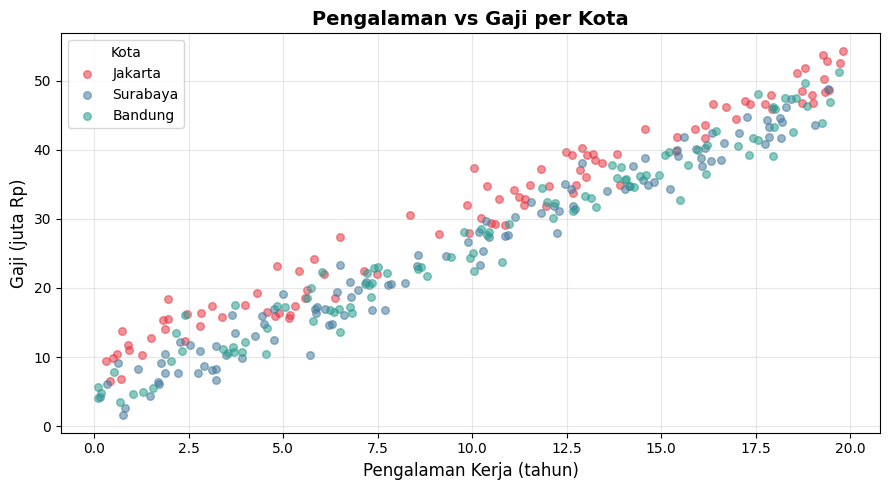

In [17]:
# Scatter plot: Pengalaman vs Gaji per Kota
fig, ax = plt.subplots(figsize=(9, 5))
palette = {'Jakarta': '#E63946', 'Surabaya': '#457B9D', 'Bandung': '#2A9D8F'}

for k, c in palette.items():
    mask = df['kota'] == k
    ax.scatter(df.loc[mask, 'pengalaman'], df.loc[mask, 'gaji'],
               label=k, alpha=0.55, color=c, s=30)

ax.set_xlabel('Pengalaman Kerja (tahun)', fontsize=12)
ax.set_ylabel('Gaji (juta Rp)', fontsize=12)
ax.set_title('Pengalaman vs Gaji per Kota', fontsize=14, fontweight='bold')
ax.legend(title='Kota')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
#Langkah 2: Preprocessing (Encoding, Split, Scaling)

# One-Hot Encoding kolom 'kota'
df_enc = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)
print('Kolom setelah encoding:', df_enc.columns.tolist())
df_enc.head(3)

# Pisahkan fitur (x) dan target (y)
X = df_enc.drop('gaji', axis=1)
y = df_enc['gaji']

# Train-Test Split — 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train : {X_train.shape[0]} baris')
print(f'Test  : {X_test.shape[0]} baris')

# StandardScaler — fit HANYA pada training set, transform keduanya
scaler     = StandardScaler()
X_train_s  = scaler.fit_transform(X_train)   # fit + transform
X_test_s   = scaler.transform(X_test)        # transform saja (cegah data leakage)

print('Scaling selesai.')
print(f'Mean X_train_s (harusnya ~0): {X_train_s.mean(axis=0).round(3)}')
print(f'Std  X_train_s (harusnya ~1): {X_train_s.std(axis=0).round(3)}')

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train : 240 baris
Test  : 60 baris
Scaling selesai.
Mean X_train_s (harusnya ~0): [-0. -0.  0.  0.]
Std  X_train_s (harusnya ~1): [1. 1. 1. 1.]


In [19]:
#Langkah 3: Latih Model & Tampilkan Koefisien

# Buat dan latih model Regresi Linear
model = LinearRegression()
model.fit(X_train_s, y_train)

print(f'β₀ (intercept) : {model.intercept_:.3f} juta Rp')
print()

coef_df = pd.DataFrame({
    'Fitur'    : X.columns,
    'Koefisien': model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)

print(coef_df.to_string(index=False))


β₀ (intercept) : 27.514 juta Rp

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


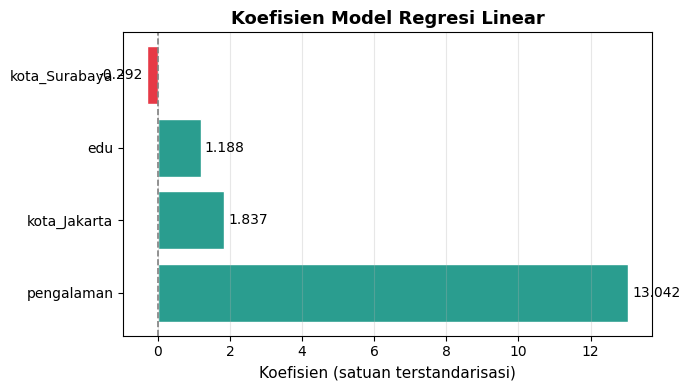

In [20]:
# Visualisasi koefisien
colors = ['#2A9D8F' if v >= 0 else '#E63946' for v in coef_df['Koefisien']]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors, edgecolor='white')
ax.axvline(0, color='gray', lw=1.2, linestyle='--')
ax.set_xlabel('Koefisien (satuan terstandarisasi)', fontsize=11)
ax.set_title('Koefisien Model Regresi Linear', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

**Interpretasi Koefisien Model**

Setelah model dilatih, koefisien yang dihasilkan menunjukkan seberapa besar pengaruh tiap fitur terhadap prediksi gaji (dalam satuan juta Rp per standar deviasi):

- `pengalaman` memiliki koefisien terbesar (~+13), artinya fitur ini paling dominan dalam menentukan gaji. Masuk akal karena dataset memang dirancang dengan bobot pengalaman yang tinggi.
- `edu` juga berpengaruh positif — tingkat pendidikan yang lebih tinggi diasosiasikan dengan gaji lebih besar, meskipun pengaruhnya lebih kecil dibanding pengalaman.
- Fitur `kota_Surabaya` bernilai negatif dibanding Jakarta sebagai baseline, mencerminkan perbedaan biaya hidup yang dimasukkan saat data digenerate.

Koefisien ini hanya berlaku dalam konteks data sintetis — pada data nyata, hubungannya bisa jauh lebih kompleks dan tidak selalu linear.

In [21]:
#Langkah 4: Evaluasi Model

# Prediksi pada test set
y_pred = model.predict(X_test_s)

# Hitung metrik evaluasi
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('=' * 40)
print('      METRIK EVALUASI MODEL')
print('=' * 40)
print(f'MAE  = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R²   = {r2:.4f}  ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE - MAE = {rmse - mae:.3f}')
print('=' * 40)

# Verifikasi R² via .score()
r2_check = model.score(X_test_s, y_test)
print(f'Verifikasi R² via .score(): {r2_check:.4f}')


      METRIK EVALUASI MODEL
MAE  = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R²   = 0.9740  (97.4% variasi dijelaskan)
Selisih RMSE - MAE = 0.474
Verifikasi R² via .score(): 0.9740


**Evaluasi Performa Model**

Tiga metrik yang digunakan untuk mengukur kualitas prediksi:

- **MAE ~1.6 juta Rp**: rata-rata selisih absolut antara prediksi dan nilai aktual. Untuk rentang gaji yang ada di dataset ini, error sebesar itu terbilang kecil.
- **RMSE** lebih besar dari MAE karena RMSE menghukum outlier lebih keras. Selisih keduanya yang tidak terlalu jauh menandakan tidak banyak error ekstrem.
- **R² mendekati 1**: model mampu menjelaskan hampir seluruh variasi data — wajar untuk dataset sintetis yang memang didesain linear dan bersih.

Perlu diingat: performa setinggi ini sangat jarang di data nyata. Data sintetis tidak punya noise yang kompleks, multikolinearitas, atau fitur tersembunyi yang mempengaruhi target.


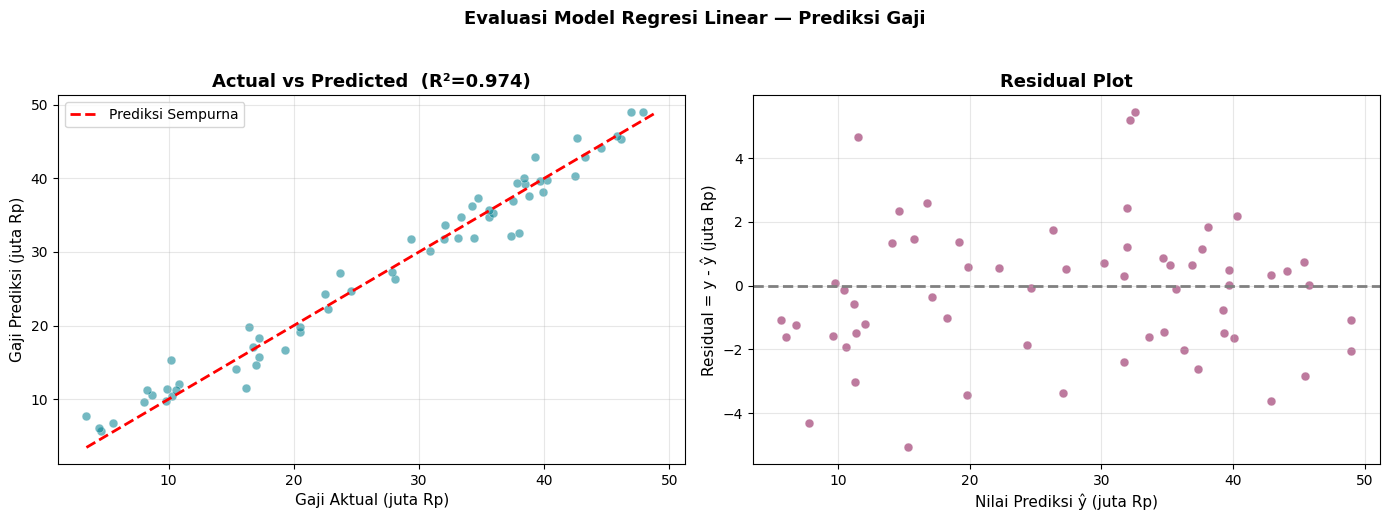

Plot tersimpan: evaluasi_regresi.png


In [22]:
#Langkah 5: Visualisasi & Interpretasi
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Actual vs Predicted ──────────────────────────────────
axes[0].scatter(y_test, y_pred, alpha=0.55, color='#028090',
                edgecolors='white', lw=0.4, s=40)
lims = [min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)', fontsize=11)
axes[0].set_ylabel('Gaji Prediksi (juta Rp)', fontsize=11)
axes[0].set_title(f'Actual vs Predicted  (R²={r2:.3f})',
                  fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Residual Plot ────────────────────────────────────────
axes[1].scatter(y_pred, residuals, alpha=0.55, color='#880E4F',
                edgecolors='white', lw=0.4, s=40)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)', fontsize=11)
axes[1].set_ylabel('Residual = y - ŷ (juta Rp)', fontsize=11)
axes[1].set_title('Residual Plot', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    'Evaluasi Model Regresi Linear — Prediksi Gaji',
    fontsize=13, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('export/evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot tersimpan: evaluasi_regresi.png')

**Membaca Dua Plot Evaluasi**

**Plot Actual vs Predicted:**
Titik-titik prediksi sangat dekat dengan garis diagonal ideal. Ini berarti model tidak secara sistematis terlalu tinggi atau terlalu rendah dalam memprediksi — distribusi error merata di sepanjang rentang nilai gaji.

**Residual Plot:**
Residual tersebar acak di sekitar y=0 tanpa membentuk pola seperti corong atau kurva. Ini mengonfirmasi dua asumsi penting Regresi Linear terpenuhi: (1) hubungan antar variabel memang linear, dan (2) varians error tidak berubah seiring bertambahnya nilai prediksi (homoscedasticity).

Kedua kondisi ini ideal — tapi ingat bahwa ini hasil dari data yang memang sengaja dibuat linear. Pada dataset dunia nyata, residual plot hampir selalu memperlihatkan pola yang lebih 'berantakan'.


# Kesimpulan

## Apa yang Dipelajari
Mempelajari penerapan Regresi Linear menggunakan scikit-learn untuk memprediksi gaji berdasarkan fitur numerik, termasuk train-test split, evaluasi model (MAE, MSE, R²), dan interpretasi visualisasi residual.

## Temuan Utama
Model Regresi Linear menghasilkan performa tinggi pada data sintetis: titik prediksi sangat dekat dengan garis ideal, dan residual tersebar acak tanpa pola sistematis — mengonfirmasi asumsi linearitas dan homoscedasticity terpenuhi.

## Keterbatasan & Pertanyaan
Dataset dihasilkan secara sintetis sehingga performa akan jauh berbeda pada data nyata yang memiliki noise dan multikolinearitas. Pertanyaan: bagaimana Regresi Ridge/Lasso menangani overfitting dibanding Regresi Linear biasa?
